In [1]:
# plt.rcParams['text.usetex'] = True
# plt.rcParams['font.family'] = 'serif'
%config InlineBackend.figure_format = 'retina'

Integral coherence time τ_c = 3.321 ps
Equivalent crystal length L_c = 5.86 mm
Residual coherence at   20.0 mm: 1.14e-06%
Residual coherence at   35.0 mm: 4.73e-23%
Residual coherence at   15.0 mm: 3.41e-03%


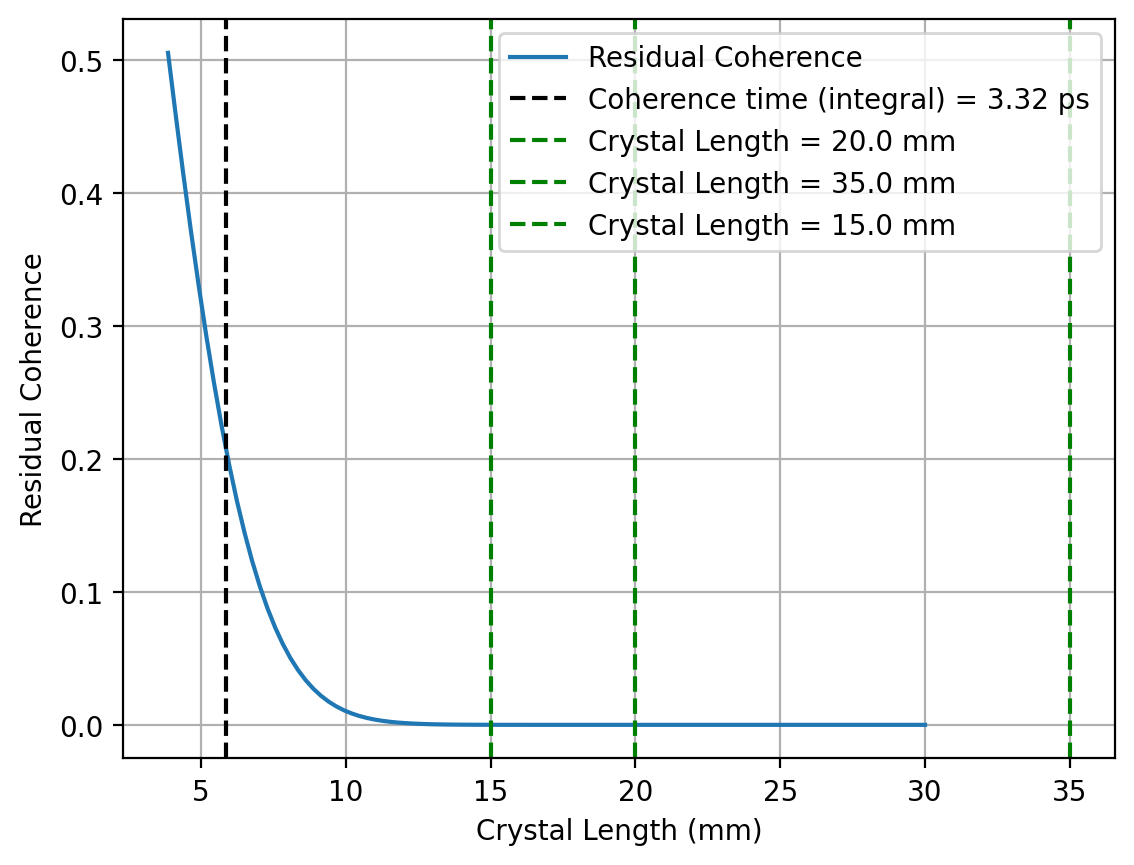

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
c = 3e8  # speed of light in m/s
wavelength = 1550e-9  # Wavelength of the photon (1550 nm)
delta_n_g = 0.17  # Group index difference (example for calcite)

# Input parameters
coherence_time = 5e-12  # Coherence time in seconds (5 ps)
spectral_bandwidth = 200e9  # Spectral bandwidth in Hz (200 GHz)

# Calculate the delay introduced by the birefringent crystal at a given length
def calc_residual_coherence(crystal_length, spectral_bandwidth, coherence_time):
    # Calculate the delay introduced by the crystal
    delta_tau = crystal_length * delta_n_g / c
    
    # Gaussian approximation for coherence function
    # gamma = np.exp(-(delta_tau/coherence_time) ** 2)  # Gaussian coherence function
    gamma = np.exp(-(np.pi * spectral_bandwidth * delta_tau) ** 2 / (4 * np.log(2)))  # Gaussian coherence function based on bandwidth
    
    return gamma

# Coherence time from the integral definition: tau_c = ∫ |γ(τ)|^2 dτ
# With γ(τ) = exp(-a τ^2), we have ∫ exp(-2a τ^2) dτ = sqrt(pi/(2a)).
a = (np.pi * spectral_bandwidth) ** 2 / (4 * np.log(2))
tau_c_integral = np.sqrt(np.pi / (2 * a))
L_c_integral = c * tau_c_integral / delta_n_g  # equivalent crystal length where Δτ(L)=tau_c

print(f"Integral coherence time τ_c = {tau_c_integral*1e12:.3f} ps")
print(f"Equivalent crystal length L_c = {L_c_integral*1e3:.2f} mm")

# Crystal length to check (in mm)
crystal1_length = 20e-3  # 12.5 mm
crystal2_length = 35e-3  # 25 mm
crystal_lengths = np.array([crystal1_length, crystal2_length, crystal2_length - crystal1_length])  # Example: 25 mm

# Calculate the residual coherence for each crystal length
residual_coherences = [calc_residual_coherence(L, spectral_bandwidth, coherence_time) for L in crystal_lengths]

# Output the result
for L, gamma in zip(crystal_lengths, residual_coherences):
    print(f"Residual coherence at {L*1e3:6.1f} mm: {gamma*100:.2e}%")

# Optional: Plot residual coherence as a function of crystal length
lengths = np.linspace(L_c_integral*1e3-2, 30, 100)*1e-3  # Check between 1 mm and 50 mm
residuals = [calc_residual_coherence(L, spectral_bandwidth, coherence_time) for L in lengths]

plt.plot(lengths*1e3, residuals, label='Residual Coherence')
# plt.axhline(y=0.001, color='r', linestyle='--', label='0.1% Residual Coherence')
plt.axvline(x=L_c_integral*1e3, color='k', linestyle='--', label=f'Coherence time (integral) = {tau_c_integral*1e12:.2f} ps')
for cl in crystal_lengths:
    plt.axvline(x=cl*1e3, color='g', linestyle='--', label=f'Crystal Length = {cl*1e3:.1f} mm')
plt.xlabel('Crystal Length (mm)')
plt.ylabel('Residual Coherence')
# plt.ylim(0, 0.5)
plt.legend()
plt.grid(True)
plt.show()

In [5]:
(1/100 -1/25 + 75/25/100)

0.0